**Table of contents**<a id='toc0_'></a>    
- 1. [Read, filter and clean data](#toc1_)    
  - 1.1. [Penn World Tables](#toc1_1_)    
  - 1.2. [IMF](#toc1_2_)    
- 2. [Merge Data](#toc2_)    
  - 2.1. [Cleaning the merged Data](#toc2_1_)    
- 3. [Descriptive statistics](#toc3_)    
  - 3.1. [lnY graph for country categories](#toc3_1_)    
  - 3.2. [Human Capital index graph for country categories](#toc3_2_)    
  - 3.3. [Initial Financial Markets Depth Index](#toc3_3_)    
  - 3.4. [Comparing Capital Stock with Financial Development](#toc3_4_)    
- 4. [Applying Kmeans clustering](#toc4_)    
  - 4.1. [Preparing data for Kmeans clustering](#toc4_1_)    
  - 4.2. [Kmeans clustering](#toc4_2_)    
  - 4.3. [Using new groups](#toc4_3_)    
  - 4.4. [Comparing Capital Stock with Financial Development - Kmeans approach](#toc4_4_)    
  - 4.5. [Plotting correlation matrix with Seaborn](#toc4_5_)    
- 5. [Penn World Table Fixed effects regression](#toc5_)    
  - 5.1. [Balancing the Penn World Table data](#toc5_1_)    
  - 5.2. [Panel Regression and results](#toc5_2_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# PWT dataproject

The project focuses on simple data cleaning, manipulation, and data exploration. The project is inspired from Mathias BA this semester, in which the dataset from PWT was cleaned and structured using Python from which paneldata analysis was conducted on the elasticity of substitution between capital and labour at aggregate level, using Stata. The focus is on importing, cleaning, and merging datasets, with some minor descriptive economics, and data analysis. We add the Financial Development Index dataset from IMF and look at correlation between Financial Development and key macroeconmic figures. Lastly, we conduct one of the Fixed Effects regressions from Mathias project, to show the further possibilities of using Python.

The PWT data includes homogenous collected, thus comparable, data on aggregate variables, from 1950-2019 for 183 countries, based on national accounts. 

In [2]:
# imports
import pandas as pd # For data manipulation
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For plotting
import ipywidgets as widgets # For possible interactive widgets
from sklearn.cluster import KMeans # For k-means clustering
from sklearn.preprocessing import StandardScaler
import seaborn as sns # For plotting

from matplotlib_venn import venn2  # For venn diagrams

# statistical modelling packages
import statsmodels # For statistical modelling
from linearmodels import PanelOLS # For panel regression

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import Countries as con # contains country groups, OECD, IMF Advanced economies, IMF Emerging economies

## 1. <a id='toc1_'></a>[Read, filter and clean data](#toc0_)

### 1.1. <a id='toc1_1_'></a>[Penn World Tables](#toc0_)
Data from the Penn World Tables (PWT) is read directly from url. The PWT dataset provides national accounts data, including GDP, capital stock, and labor input, which are crucial for macroeconomic analysis. We will use this dataset to explore economic indicators across different countries and years.

In [3]:
# URL of the stata file
pwt_url = "https://dataverse.nl/api/access/datafile/354098"

# Read the stata file into a DataFrame
pwt = pd.read_stata(pwt_url)
country_total = len(pwt.countrycode.unique())

# Get the total number of unique countries and other dataset dimensions
print(f'There are {country_total} unique countries in the dataframe, {len(pwt.year.unique())} unique years, {len(pwt.index)} rows in total, and {len(pwt.columns)} columns')

There are 183 unique countries in the dataframe, 70 unique years, 12810 rows in total, and 52 columns


Some variables are renamed to familiar terms. \
The variable "hc" is a human capital index, "labsh" is the labor share of compensation, Y, K, and L, are gross GDP, Capital stock and labor, respectively. \
The dataframe is filtered to the variables of interest, which are chosen since they are the variables needed for the estimation in the last section. 

In [4]:
# Rename variables to well-known economic terms
pwt = pwt.rename(columns = {'rgdpna':'Y', "rnna":"K", "emp": "L"})

# Define variables of interest
var_of_int_pwt = ["countrycode","country", "year", "Y", "K", "L", "hc", "labsh"]

# Filter to only include variables of interest
pwt = pwt[var_of_int_pwt]

The data from the Penn World Tables can now be cleaned and various transformations applied. These transformations align the data with the requirements of Mathias' BA project, aiming to estimate the elasticity of substitution between capital and labor. Specifically, we transform variables to fit the linear equation found in Mathias BA project, that is: $$\ln a_{it} = c_i + d_t-\varphi \ln x_{it} + \epsilon_{it}$$ 
Where $a = r\frac{K}{Y}$, and $x=\frac{K}{Y}$.

In [7]:
# Drop NaN-values and reset index
pwt.dropna(inplace=True)
pwt.reset_index(inplace=True, drop=True) 

# Generate variables of interest
pwt["cap_out"] = pwt["K"] / pwt["Y"] # capital output ratio
pwt["HC"] = pwt["hc"] * pwt["L"] # aggregate human capital
pwt["capsh"] = 1 - pwt["labsh"] # capital share as reciproc of labsh

# Make log transformations
pwt["lnY"] = np.log(pwt["Y"])
pwt["lnK"] = np.log(pwt["K"])
pwt["ln_capsh"] = np.log(pwt["capsh"])
pwt["ln_labsh"] = np.log(pwt["labsh"])
pwt["ln_cap_out"] = np.log(pwt["K"] / pwt["Y"])
pwt["ln_cap_out_neg"] = -np.log(pwt["K"] / pwt["Y"])

# Sort values by countrycode and year to make functions possible
pwt.sort_values(by=["countrycode", "year"])

,countrycode,country,year,Y,K,L,hc,labsh,cap_out,HC,capsh,lnY,lnK,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg
0,AGO,Angola,1970,54237.054688,257238.093750,3.666207,1.015686,0.284385,4.742848,3.723715,0.715615,10.901119,12.457757,-0.334612,-1.257427,1.556638,-1.556638
1,AGO,Angola,1971,57491.277344,274282.500000,3.742484,1.018196,0.284385,4.770854,3.810581,0.715615,10.959389,12.521914,-0.334612,-1.257427,1.562525,-1.562525
2,AGO,Angola,1972,57606.261719,290921.906250,3.853271,1.020712,0.284385,5.050179,3.933079,0.715615,10.961387,12.580811,-0.334612,-1.257427,1.619424,-1.619424
3,AGO,Angola,1973,62272.367188,309321.281250,3.987807,1.023234,0.284385,4.967232,4.080459,0.715615,11.039273,12.642136,-0.334612,-1.257427,1.602863,-1.602863
4,AGO,Angola,1974,64202.808594,328087.000000,4.130696,1.025762,0.284385,5.110166,4.237112,0.715615,11.069802,12.701035,-0.334612,-1.257427,1.631232,-1.631232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6809,ZWE,Zimbabwe,2015,42008.199219,53550.226562,6.393752,2.584653,0.533381,1.274757,16.525631,0.466619,10.645620,10.888375,-0.762242,-0.628519,0.242755,-0.242755
6810,ZWE,Zimbabwe,2016,42325.726562,55167.007812,6.504374,2.616257,0.533381,1.303392,17.017117,0.466619,10.653151,10.918120,-0.762242,-0.628519,0.264970,-0.264970
6811,ZWE,Zimbabwe,2017,44316.742188,56829.140625,6.611773,2.648248,0.533381,1.282340,17.509615,0.466619,10.699118,10.947804,-0.762242,-0.628519,0.248687,-0.248687
6812,ZWE,Zimbabwe,2018,46457.097656,58552.808594,6.714952,2.680630,0.533381,1.260363,18.000299,0.466619,10.746284,10.977684,-0.762242,-0.628519,0.231400,-0.231400


### 1.2. <a id='toc1_2_'></a>[IMF](#toc0_)
To enhance our analysis, we incorporate financial development data from the IMF. This dataset includes indices that measure various dimensions of financial development, such as Financial Development (FD), Financial Institution Depth (FID), and Financial Market Depth (FMD). These are 3 of 9 indices that aim to capture the complex multidimensional structure of financial development, created by IMF. For more details on the methodology, refer to the IMF [methodology paper](https://data.imf.org/?sk=f8032e80-b36c-43b1-ac26-493c5b1cd33b).

In [8]:
# Read IMF data from local excel file
imf = pd.read_excel("data/FD Index Database (Excel).xlsx")

# Define variables of interest
var_of_int_imf = ['country','year','FD','FID','FMD']

# Filter to only include variables of interest
imf = imf[var_of_int_imf]

## 2. <a id='toc2_'></a>[Merge Data](#toc0_)

To create a comprehensive dataset that includes both macroeconomic indicators and financial development indices, we merge the PWT dataset with the IMF dataset into "pwt_and_imf". This merge is performed using a left join on the common keys: country and year. This ensures that all records from the IMF dataset are included, along with their corresponding PWT values.

To ensure that the merge is succesfull, the number of rows in the "pwt_and_imf" is checked, which should correspond to the number of rows in "imf". 

In [11]:
# Merge the two dataframes
pwt_and_imf = pd.merge(imf, pwt, how='left', on=['country', 'year'])

# Check shape of the merged dataframe
if pwt_and_imf.shape[0] == imf.shape[0]:
    print("The merge was successful")

The merge was successful


The merged dataframe "pwt_and_imf" has the same number of rows as the left dataframe in the merge, meaning the 'left-join' worked as expected.

To make the descriptive analysis as simple as possible, the countries are divided into three groups. The groups can be inspected in the file "Countries.py". A function is now defined that takes the countrycode and assigns the countries into the three groups. Note, that the groups OECD and IMF Advanced have a big overlap, but was originally done in Mathias project to encompass all possibilities in regards to his supervisors wishes and suggestions. It offers little insight to include both, but the main scope of the project is data cleaning etc. and as such, the extra group serves merely the purpose of being an extra group. 

In [12]:
# Function to categorize countries and return a dictionary of categories
def categorize_country(countrycode):
    categories = {'OECD': 0, 'IMF Advanced': 0, 'IMF Emerging': 0, 'Other': 0}
    if countrycode in con.oecd_countries:
        categories['OECD'] = 1
    if countrycode in con.imf_advanced_countries:
        categories['IMF Advanced'] = 1
    if countrycode in con.imf_emerging_countries:
        categories['IMF Emerging'] = 1
    if categories.values() == [0, 0, 0, 0]:
        categories['Other'] = 1
    return categories

# Create a new column in the DataFrame with the country category
dummy_columns = pwt_and_imf['countrycode'].apply(categorize_country).apply(pd.Series)

# Concatenate the original DataFrame with the dummy columns
pwt_and_imf = pd.concat([pwt_and_imf, dummy_columns], axis=1)



### 2.1. <a id='toc2_1_'></a>[Cleaning the merged Data](#toc0_)

We now clean the newly merged dataframe, for NaN values, and missing observations. 

In [13]:
# Drop na 
pwt_and_imf = pwt_and_imf.dropna()

# Group by 'country' and count the number of observations
country_counts = pwt_and_imf['country'].value_counts()

# Filter out countries with less than 40 observations
countries_with_40_or_more_observations = country_counts[country_counts >= 40].index

# Filter the original DataFrame based on the selected countries
pwt_and_imf = pwt_and_imf[pwt_and_imf['country'].isin(countries_with_40_or_more_observations)].reset_index(drop=True)

# Check that there aren't any NaN-values
nan_count_per_column = pwt_and_imf.isna().sum()

# Utilize that 0 is a boolean value for False, why the sum of the pandas core series must be 0 if there are none NaN-values
print(nan_count_per_column.sum() == 0)

True


In [14]:
pwt_and_imf.head()

,country,year,FD,FID,FMD,countrycode,Y,K,L,hc,...,lnY,lnK,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg,OECD,IMF Advanced,IMF Emerging,Other
0,Angola,2019,0.096969,0.045453,0.100247,AGO,222151.062500,1300951.000,16.644962,1.481984,...,12.311113,14.078606,-0.402184,-1.105207,1.767493,-1.767493,0,0,1,0
1,Angola,2018,0.144027,0.043575,0.066922,AGO,225540.046875,1292107.750,16.078331,1.474635,...,12.326253,14.071785,-0.402184,-1.105207,1.745532,-1.745532,0,0,1,0
2,Angola,2017,0.148656,0.049994,0.067229,AGO,230151.343750,1281953.250,15.544552,1.467321,...,12.346493,14.063895,-0.425215,-1.060246,1.717403,-1.717403,0,0,1,0
3,Angola,2016,0.154190,0.056435,0.094943,AGO,230491.171875,1267231.125,15.028339,1.460044,...,12.347968,14.052345,-0.420109,-1.069952,1.704377,-1.704377,0,0,1,0
4,Angola,2015,0.147570,0.070821,0.075656,AGO,236594.859375,1233630.000,14.529098,1.452803,...,12.374104,14.025472,-0.429442,-1.052318,1.651367,-1.651367,0,0,1,0


## 3. <a id='toc3_'></a>[Descriptive statistics](#toc0_)

In this part of the project, we present graphs of some descriptive statistics, the GDP and Human Capital index series, 

### 3.1. <a id='toc3_1_'></a>[lnY graph for country categories](#toc0_)

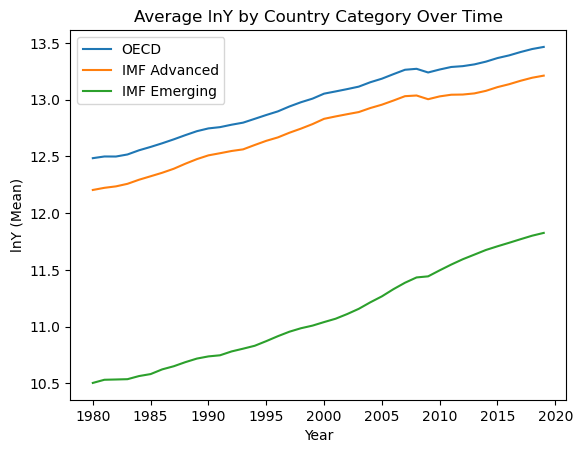

In [15]:
# Use a split-apply to group the observations after year and country_category and then calculate the mean for the country category in the specific year
oecd_y     = pwt_and_imf[pwt_and_imf['OECD']==1].groupby('year')['lnY'].mean().reset_index()
advanced_y = pwt_and_imf[pwt_and_imf['IMF Advanced']==1].groupby('year')['lnY'].mean().reset_index()
emerging_y = pwt_and_imf[pwt_and_imf['IMF Emerging']==1].groupby('year')['lnY'].mean().reset_index()


# Plotting OECD data
plt.plot(oecd_y['year'], oecd_y['lnY'], label='OECD')

# Plotting Advanced data
plt.plot(advanced_y['year'], advanced_y['lnY'], label='IMF Advanced')

# Plotting Emerging data
plt.plot(emerging_y['year'], emerging_y['lnY'], label='IMF Emerging')

# Adding labels and title
plt.xlabel('Year')
plt.ylabel('lnY (Mean)')
plt.title('Average lnY by Country Category Over Time')
plt.legend()

# Display the plot
plt.show()

From the graph we see that for all groups, the mean GDP has been increasing since 1980. The emerging economies have a lower level but the distance between the lines, have become marginally smaller, inidicating faster growth for the emerging economies in the period. Furthermore, the difference between the IMF advanced and OECD is small since they consist of mainly the same countries. 

### 3.2. <a id='toc3_2_'></a>[Human Capital index graph for country categories](#toc0_)

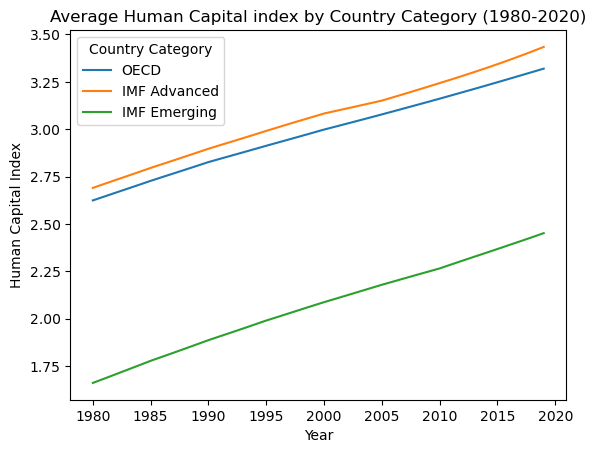

In [16]:
# Use a split-apply to group the observations after year and country_category and then calculate the mean for the country category in the specific year
oecd_hc     = pwt_and_imf[pwt_and_imf['OECD']==1].groupby('year')['hc'].mean().reset_index()
advanced_hc = pwt_and_imf[pwt_and_imf['IMF Advanced']==1].groupby('year')['hc'].mean().reset_index()
emerging_hc = pwt_and_imf[pwt_and_imf['IMF Emerging']==1].groupby('year')['hc'].mean().reset_index()


# Plotting OECD data
plt.plot(oecd_hc['year'], oecd_hc['hc'], label='OECD')

# Plotting Advanced data
plt.plot(advanced_hc['year'], advanced_hc['hc'], label='IMF Advanced')

# Plotting Emerging data
plt.plot(emerging_hc['year'], emerging_hc['hc'], label='IMF Emerging')

# Adding labels and title
plt.title('Average Human Capital index by Country Category (1980-2020)')
plt.xlabel('Year')
plt.ylabel('Human Capital Index')

# Adding legend
plt.legend(title='Country Category')

# Show plot
plt.show()

In [17]:
# Small analysis of the difference in human capital between advanced and emerging economies
dist = (advanced_hc-emerging_hc)
dist_mean = np.mean(dist['hc'])
dist_std = np.std(dist['hc'])
dist_mean, dist_std

# correlation between human capital and lnY
correlation = pwt_and_imf['hc'].corr(pwt_and_imf['lnY'])

# Print correlation, distance mean and distance standard deviation
correlation, dist_mean, dist_std

(0.5334096739804136, 0.9949993, 0.018342232331633568)

We see a similar picture here, but with the gap being seemingly constant. This and the small analysis above shows a strong positive correlation between GDP and Human Capital index, and again, the emerging economies have a lower level than their advanced counterparts. 

### 3.3. <a id='toc3_3_'></a>[Initial Financial Markets Depth Index](#toc0_)

The intitial Financial Markets Depth Index (FMD) can now be inspected in order to gain an understanding of the state of financial markets in 1980 around the world.

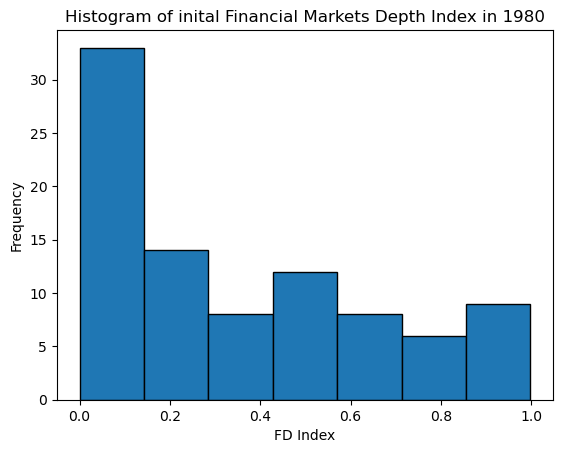

In [24]:
# Define a pandas core series as a split-apply to group the observations by country and compute the first observation for FMD
initial_FMD = pwt_and_imf.groupby('country')['FMD'].first().reset_index()

# Plotting
plt.hist(initial_FMD['FMD'], bins=7, edgecolor='black')

# Adding labels and titles
plt.title('Histogram of inital Financial Markets Depth Index in 1980')
plt.xlabel('FD Index')
plt.ylabel('Frequency')

# Show plot
plt.show()

Three categories can be made to distungish the countries' initial FDM index. In this way providing an overview of the number of countries in each category.

In [25]:
# Use the numpy linspace command to create three discrete intervals for the FMD-values and assign them names
bins = np.linspace(0, 1, num=4)
labels = ['Low FDM countries', 'Medium FDM countries', 'High FDM countries']

# Use the pandas cut command to divide the initial_FMD dataframe into the three discrete intervals
initial_FMD['FD_Category'] = pd.cut(initial_FMD['FMD'], bins=bins, labels=labels, right=False)

# Merge the categories back into the main DataFrame
pwt_and_imf_wFMD = pd.merge(pwt_and_imf, initial_FMD[['country', 'FD_Category']], on='country', how='left')

c:\Users\mathi\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


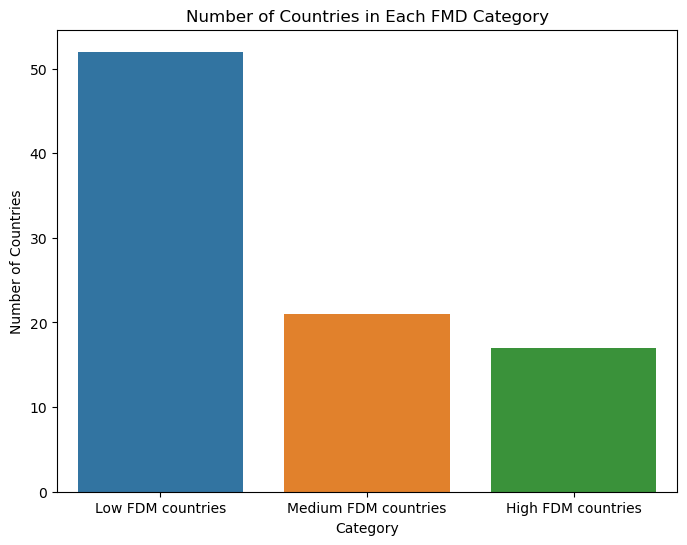

In [26]:
# Assuming 'FD_Category' is the column containing the categories
category_counts = pwt_and_imf_wFMD['FD_Category'].value_counts()/len(pwt_and_imf_wFMD['year'].unique())

# Plotting the number of countries in each category
plt.figure(figsize=(8, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title('Number of Countries in Each FMD Category')
plt.xlabel('Category')
plt.ylabel('Number of Countries')
plt.show()

### 3.4. <a id='toc3_4_'></a>[Comparing Capital Stock with Financial Development](#toc0_)

Next we want to see if there is any correlation or relationship between the capital stock and financial development. We assume there is a positive relationship, and since we know capital has been increasing, we would expect to see the financial development depth increasing similarly. 

C:\Users\mathi\AppData\Local\Temp\ipykernel_8564\944720388.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_K = pwt_and_imf_wFMD.groupby(['year', 'FD_Category'])['K'].mean().unstack() # Average Capital stock each specific year distributed on FD categories
C:\Users\mathi\AppData\Local\Temp\ipykernel_8564\944720388.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_FMD = pwt_and_imf_wFMD.groupby(['year', 'FD_Category'])['FMD'].mean().unstack() # Average FMD index each specific year distributed on FD categories


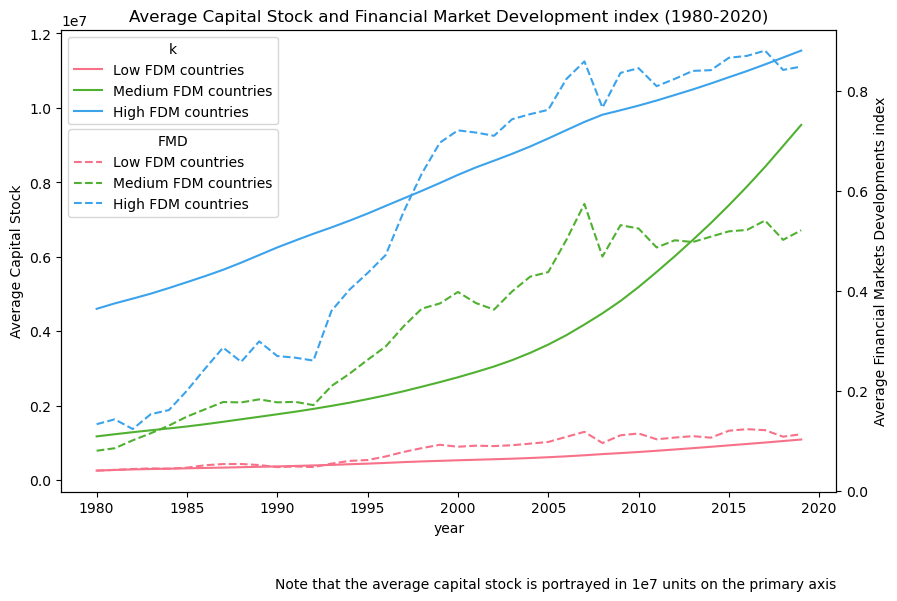

In [27]:
# Make two new dataframes by split-apply
avg_K = pwt_and_imf_wFMD.groupby(['year', 'FD_Category'])['K'].mean().unstack() # Average Capital stock each specific year distributed on FD categories
avg_FMD = pwt_and_imf_wFMD.groupby(['year', 'FD_Category'])['FMD'].mean().unstack() # Average FMD index each specific year distributed on FD categories

# Define custom color palette
custom_palette = sns.color_palette("husl", n_colors=len(avg_K.columns))

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot avg_K on primary axis
avg_K.plot(ax=ax1, color=custom_palette)
ax1.set_ylabel('Average Capital Stock')

# Create secondary axis
ax2 = ax1.twinx()

# Plot avg_FMD on secondary axis
avg_FMD.plot(ax=ax2, linestyle='--', color=custom_palette)
ax2.set_ylabel('Average Financial Markets Developments index')

# Add labels and title
plt.title('Average Capital Stock and Financial Market Development index (1980-2020)')
plt.xlabel('Year')

# Add a footnote to avoid confusion about the unit of the average capital stock
ax1.annotate('Note that the average capital stock is portrayed in 1e7 units on the primary axis',
            xy = (1.0, -0.2),          # Lower x -> further to the left, Lower y -> further upwards
            xycoords='axes fraction',
            ha='right',
            va="center",
            fontsize=10)

# Add legend
legend1 = ax1.legend(title='k', loc='upper left', bbox_to_anchor=(0, 1))
legend2 = ax2.legend(title='FMD', loc='upper left', bbox_to_anchor=(0, 0.8))

# Show plot
plt.show()


As expected, both capital and FMD has been increasing on average over each country group. The low FDM countries hav seen relatively little growth in their capital stock and FDM compared to higher FDM groups. 

## 4. <a id='toc4_'></a>[Applying Kmeans clustering](#toc0_)

### 4.1. <a id='toc4_1_'></a>[Preparing data for Kmeans clustering](#toc0_)
In order to be able to apply machine learning by Kmeans clustering, the data must: 
1. Be factorized such that the countries appear by a code and not be country name 
2. Irrelevant variables must be dropped
3. Since the purpose of the Kmeans clustering is to use ML to determine new groups based on initial values by key variables, only the initial values are kept. 
4. The data must be fitted and transformed

In [28]:
pwt_and_imf_wFMD_kmeans = pwt_and_imf_wFMD.copy()

# Create new column, which contains a code for the specific countries (codes: 1-90)
pwt_and_imf_wFMD_kmeans['code'] = pd.factorize(pwt_and_imf_wFMD_kmeans['country'])[0]+1

# Filter out variables that aren't of interest
filtered_df_kmeans = pwt_and_imf_wFMD_kmeans[['code','FD','FID','FMD','hc','lnY','ln_capsh']]

# Use split-apply to group observations after (country) code and then choose the first observation for the specific country to use initial values
filtered_df_kmeans_first_values = filtered_df_kmeans.groupby('code').first().reset_index()

# Fit and transform data to standardize
scaler = StandardScaler()
filtered_df_kmeans_first_values_scaled = scaler.fit_transform(filtered_df_kmeans_first_values)

# Statistics of scaled data
pd.DataFrame(filtered_df_kmeans_first_values_scaled).describe()

,0,1,2,3,4,5,6
count,9.000000e+01,9.000000e+01,9.000000e+01,9.000000e+01,9.000000e+01,9.000000e+01,9.000000e+01
mean,1.480297e-17,-5.057683e-17,1.233581e-17,-6.167906e-18,1.884295e-16,-4.564250e-17,1.147230e-16
std,1.005602e+00,1.005602e+00,1.005602e+00,1.005602e+00,1.005602e+00,1.005602e+00,1.005602e+00
min,-1.712912e+00,-1.567098e+00,-1.208780e+00,-1.121694e+00,-2.198240e+00,-2.147210e+00,-3.518511e+00
25%,-8.564558e-01,-9.250912e-01,-8.361270e-01,-9.151541e-01,-6.795676e-01,-8.750055e-01,-5.394981e-01
50%,0.000000e+00,-1.261145e-01,-4.229279e-01,-3.334379e-01,1.087506e-01,5.367174e-02,-2.246098e-02
75%,8.564558e-01,8.861540e-01,9.125345e-01,7.411106e-01,6.833190e-01,7.019743e-01,6.390706e-01
max,1.712912e+00,2.059736e+00,2.071285e+00,2.097018e+00,2.319758e+00,2.393955e+00,2.222287e+00


### 4.2. <a id='toc4_2_'></a>[Kmeans clustering](#toc0_)

In [41]:
# Defining the kmeans function with initialization as k-means++
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=100)

# Fitting the k means algorithm on scaled data
kmeans.fit(filtered_df_kmeans_first_values_scaled)
pred = kmeans.predict(filtered_df_kmeans_first_values_scaled)

# Inertia on the fitted data
kmeans.inertia_

# Unpack the counts of the three different Kmens groups
unique, counts = np.unique(pred, return_counts=True)
unique, counts

c:\Users\mathi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


(array([0, 1, 2]), array([23, 28, 39], dtype=int64))

### 4.3. <a id='toc4_3_'></a>[Using new groups](#toc0_)

In [44]:
# Create a new column in the unscaled df that was used for Kmeans clustering, assign the labels that Kmeans distributed
filtered_df_kmeans_first_values['Kmeans_label'] = kmeans.labels_

# Merge the copy of the merged pwt and imf data with the kmeans labels using a left-join
pwt_and_imf_wFMD_kmeans_finalgroups = pd.merge(pwt_and_imf_wFMD_kmeans,filtered_df_kmeans_first_values[['code','Kmeans_label']], how='left', on='code')

Lets illustrate how the countries have been grouped in these Kmeans clusters, based on selected economic indicators.

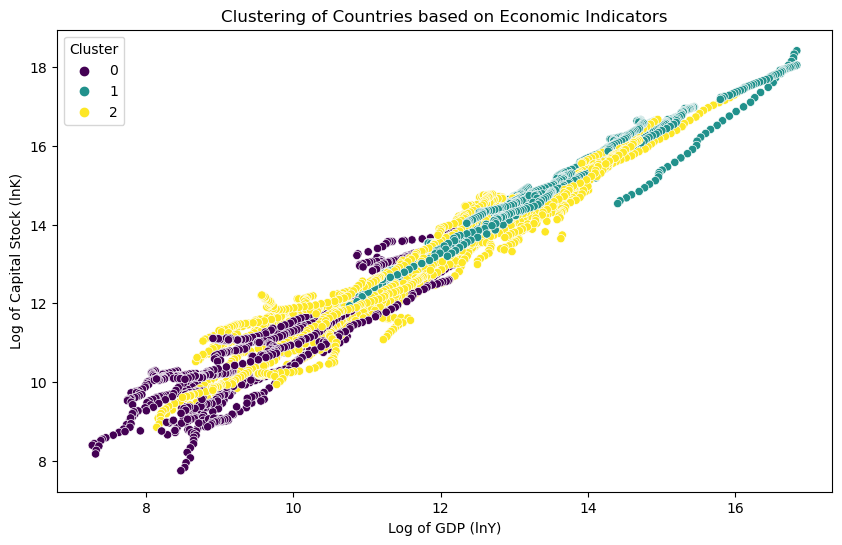

In [ ]:
# Plotting clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='lnY', y='lnK', hue="Kmeans_label", data=pwt_and_imf_wFMD_kmeans_finalgroups, palette='viridis', legend='full')
plt.title('Clustering of Countries based on Economic Indicators')
plt.xlabel('Log of GDP (lnY)')
plt.ylabel('Log of Capital Stock (lnK)')
plt.legend(title='Cluster')
plt.show()

The scatter plot above shows the clustering of countries based on selected economic indicators such as GDP, capital stock. The colors represent different clusters identified by the K-means algorithm.

These clusters help us understand the economic similarities and differences among countries, providing insights into their development stages and financial structures.

In [50]:
klabels = pwt_and_imf_wFMD_kmeans_finalgroups['Kmeans_label'].unique()

country_bins = []

year_slice = pwt_and_imf_wFMD_kmeans_finalgroups[pwt_and_imf_wFMD_kmeans_finalgroups['year']==2000]

for label in klabels:
    temp = year_slice[year_slice['Kmeans_label']==label]
    temp = temp['country'].reset_index()
    temp = temp.rename(columns={'country':f'Group: {label}'})
    country_bins.append(temp)

category_df = pd.concat(country_bins, axis=1)

category_df = category_df[['Group: 0','Group: 1','Group: 2',]]

category_df

,Group: 0,Group: 1,Group: 2
0,Angola,Australia,Argentina
1,Burundi,Austria,Bulgaria
2,Benin,Belgium,Bahrain
3,Burkina Faso,Brazil,Botswana
4,Barbados,Canada,Colombia
5,Central African Republic,Switzerland,Costa Rica
6,Cameroon,Chile,Cyprus
7,Ecuador,China,Dominican Republic
8,Fiji,Germany,Gabon
9,Guatemala,Denmark,Greece


### 4.4. <a id='toc4_4_'></a>[Comparing Capital Stock with Financial Development - Kmeans approach](#toc0_)

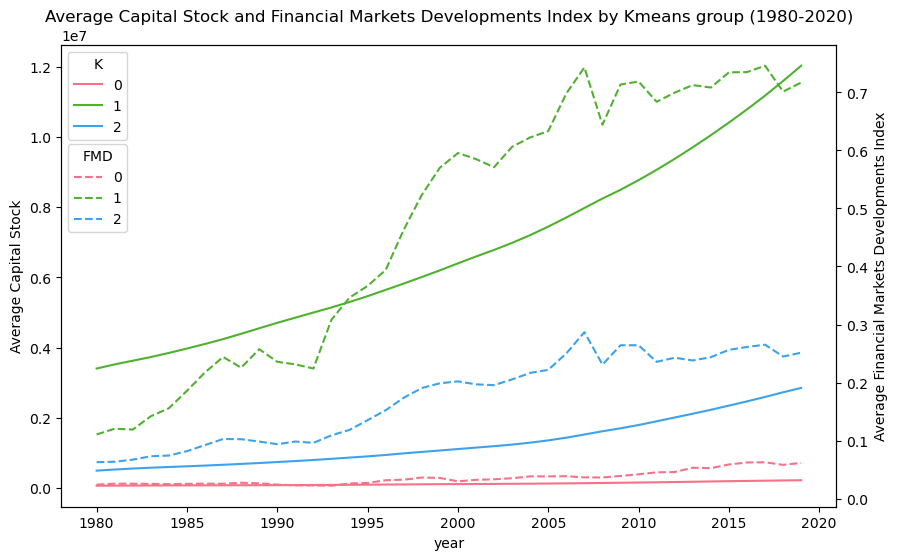

In [51]:
# Calculate the mean for each Kmeans-group for each year for both capital stock and FMD-index
avg_K2 = pwt_and_imf_wFMD_kmeans_finalgroups.groupby(['year', 'Kmeans_label'])['K'].mean().unstack()
avg_FMD2 = pwt_and_imf_wFMD_kmeans_finalgroups.groupby(['year', 'Kmeans_label'])['FMD'].mean().unstack()

# Define custom color palette
custom_palette = sns.color_palette("husl", n_colors=len(avg_K2.columns))

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot avg_K2 on primary axis
avg_K2.plot(ax=ax1, color=custom_palette)
ax1.set_ylabel('Average Capital Stock')

# Create secondary axis
ax2 = ax1.twinx()

# Plot avg_FMD2 on secondary axis
avg_FMD2.plot(ax=ax2, linestyle='--', color=custom_palette)
ax2.set_ylabel('Average Financial Markets Developments Index')

# Adding labels and title
plt.title('Average Capital Stock and Financial Markets Developments Index by Kmeans group (1980-2020)')
plt.xlabel('Year')

# Adding legend
legend1 = ax1.legend(title='K', loc='upper left', bbox_to_anchor=(0, 1))
legend2 = ax2.legend(title='FMD', loc='upper left', bbox_to_anchor=(0, 0.8))

# Show plot
plt.show()


The graph above paint a similar picture as earlier. It seems that with the new groups, the lowest FMD countries, havent increased their FMD on average. There is also now a clearing distinction between group 1 and 2. 

### 4.5. <a id='toc4_5_'></a>[Plotting correlation matrix with Seaborn](#toc0_)

We wanted to see if there was any correlation between these macroeconomic indicators, and the financial development level. It would then seem obvious to use a correlation matrix. 

In [52]:
heatmap_variables = ['lnY','lnK','hc','FD','FMD','FID']
pwt_and_imf_hm_variables = pwt_and_imf[heatmap_variables].reset_index(drop=True)

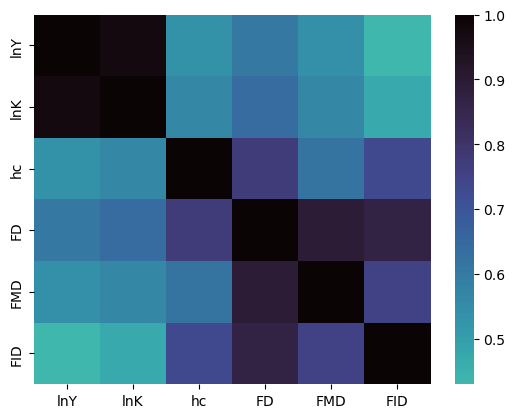

In [53]:
correlations = pwt_and_imf_hm_variables.corr()
sns.heatmap(correlations, cmap='mako_r', center=0.6)
plt.show()

The illustration of the correlation matrix is mirrored across the diagonal. We see a positive correlation between all variables and indicies, most interestingly, the Human Capital Index has the highest correlation with the financial development indices. They are however all relatively high, above 0.45, which is to be expected. 

## 5. <a id='toc5_'></a>[Penn World Table Fixed effects regression](#toc0_)
The last part of the project will focus on doing a fixed effects estimation of the panel data from PWT, which is an OLS regression on the within-transformation of the equation presented earlier, $\ln a_{it} = c_i + d_t-\varphi \ln x_{it} + \epsilon_{it}$. The IMF data will no longer be used but the country groups from the Countries.py will be. This is merely done to show that more advanced statistical methods are possible in python, other than descriptive statistics and data cleaning/structuring. In Mathias BA, the analysis is expanded much, including Non-Linear estimation, and more advanced linear estimation techniques. It would definitely be possible to write the numerical optimization algorithm used in Stata in regards to NLS, but is out this projects scope.  

In [54]:
# A new df is made as a copy of the original imported pwt df
world_data = pwt.copy()

# Define new dataframes as the country groups in the py-file
oecd_data = pwt[pwt['countrycode'].isin(con.oecd_countries)]
imf_advanced_data = pwt[pwt['countrycode'].isin(con.imf_advanced_countries)]
imf_emerging_data = pwt[pwt['countrycode'].isin(con.imf_emerging_countries)]

### 5.1. <a id='toc5_1_'></a>[Balancing the Penn World Table data](#toc0_)

In order to do a panel fixed effects estimation, the panel data should preferably be balanced, meaning that the each unique ID (country) has the same amount of observations. In the effort to balance the panel, it is decided that the latest allowed "starting point" for observations is 1960. to keep as much as the time dependent variation as possible. Therefore all countries that has its first observations after 1960 are filtered out.

In [55]:
# Group by country code and find the minimum year for each country
min_years_by_country = pwt.groupby('countrycode')['year'].min()

# Define a list of countries which corresponds to the minimum year being less than or equal to 1960
countries_before_1960 = min_years_by_country[min_years_by_country <= 1960].index

# Filter the DataFrame to include only countries with starting year before or in 1960
balanced_data = pwt[pwt['countrycode'].isin(countries_before_1960)]

# Filter out all observations before 1960
balanced_data = balanced_data[balanced_data['year'] > 1959]

# Filtering the data into the 4 groups 
world_bal_data = balanced_data.copy()
oecd_bal_data = balanced_data[balanced_data['countrycode'].isin(con.oecd_countries)]
imf_advanced_bal_data = balanced_data[balanced_data['countrycode'].isin(con.imf_advanced_countries)]
imf_emerging_bal_data = balanced_data[balanced_data['countrycode'].isin(con.imf_emerging_countries)]


To check whether the restriction in using 1960 as the cutoff year for balancing was reasonable, we are interested in seing how many countries were omitted. 

In [56]:
# How many countries are removed 
num_countries_before = len(pwt['countrycode'].unique())
num_countries_after = len(balanced_data['countrycode'].unique())

# Define functions to calculate the number of countries in each group
def num_countries_in_group(group_name, country_list):
    return len(pwt[pwt['countrycode'].isin(country_list)]['countrycode'].unique())

def num_countries_in_group_after_filter(group_name, country_list):
    return len(balanced_data[balanced_data['countrycode'].isin(country_list)]['countrycode'].unique())

# Calculate the number of countries in each group before filtering
num_countries_in_groups_before = {
    "world": num_countries_in_group("world", pwt['countrycode'].unique()),
    "oecd": num_countries_in_group("oecd", con.oecd_countries),
    "imf_advanced": num_countries_in_group("imf_advanced", con.imf_advanced_countries),
    "imf_emerging": num_countries_in_group("imf_emerging", con.imf_emerging_countries)
}

# Calculate the number of countries in each group after filtering
num_countries_in_groups_after = {
    "world": num_countries_in_group_after_filter("world", pwt['countrycode'].unique()),
    "oecd": num_countries_in_group_after_filter("oecd", con.oecd_countries),
    "imf_advanced": num_countries_in_group_after_filter("imf_advanced", con.imf_advanced_countries),
    "imf_emerging": num_countries_in_group_after_filter("imf_emerging", con.imf_emerging_countries)
}

# Calculate the number of countries removed from each group
num_countries_removed_from_groups = {
    group: num_countries_in_groups_before[group] - num_countries_in_groups_after[group]
    for group in num_countries_in_groups_before
}

# Print the results
for group, num_removed in num_countries_removed_from_groups.items():
    print(f"Number of countries removed from {group} group: {num_removed}")

Number of countries removed from world group: 40
Number of countries removed from oecd group: 8
Number of countries removed from imf_advanced group: 8
Number of countries removed from imf_emerging group: 32


In [57]:
# How many countries are removed
print(f'The PWT dataset contained {country_total}, filtering from 1960 brought it down to {num_countries_before} and removing the countries that had any number of NaN values, we end with {num_countries_after}')

The PWT dataset contained 183, filtering from 1960 brought it down to 118 and removing the countries that had any number of NaN values, we end with 78


We lose over 100 countries in the process, but the countries lost, are those of lesser quality, and as such, it is deemed a reasonable descision. It is a trade-off between time-periods versus countries. 

### 5.2. <a id='toc5_2_'></a>[Panel Regression and results](#toc0_)


Estimating the Elasticity of Substitution between capital and labour, $\sigma$, defined as $\sigma=\frac{1}{1+\phi}$, is done from the following equation $\ln a_{it} = c_i + d_t-\varphi \ln x_{it} + \epsilon_{it}$, which follows from a CES production function, using some algebraic manipulation and the first order condition for capital, assuming competitive markets. These variables are naturally stationary, which should resolve possible stationarity issues. We use clustered standard errors to correct for crosssectional dependence, autocorrelation and heteroskedasticity. We estimate $\varphi$ and thus implicitly $\sigma$ which is a non-linear combination. If we wanted the standard errors for this combination we would employ the delta method. 

We include fixed effects to capture the unobserved characteristics of countries, i.e. any factors that are constant over time for each individual but different across countries. This could be differences in institutions, culture, natural ressources. 

We include time effects to similarly capture the unobserved factors that affect all countries in the panel simultanously across time periods. This could be macroeconomic conditions such as global economic cycles, technological changes or policy shifts.  

In [58]:
# Define the fixed effects OLS estimator function
def fixed_effects(data, fixed_effects, time_effects):
    # Index data after countrycode and then year
    data = data.set_index(["countrycode", "year"])

    # Define the ln of capital share
    a = data["ln_capsh"]

    # Define the ln of the negative capital-output-ratio
    cap_out = data["ln_cap_out_neg"]
    
    # Estimate using the PanelOLS package
    res = PanelOLS(a, cap_out, entity_effects=fixed_effects, time_effects=time_effects).fit(cov_type="clustered", cluster_entity=True)

    # Unpack solution for sigma
    sigma = 1/(1+res.params)
    return sigma


The Elasticity of Substitution between capital and labor can now be examined for the different country groups.

In [60]:
print(f'''Estimation of the Elasticity of Substitution
    \n World: {fixed_effects(world_bal_data,True,True).iloc[0]:.2f}
    \n OECD: {fixed_effects(oecd_bal_data,True,True).iloc[0]:.2f} 
    \n IMF Emerging: {fixed_effects(imf_emerging_bal_data,True,True).iloc[0]:.2f}
    \n IMF Advanced: {fixed_effects(imf_advanced_bal_data,True,True).iloc[0]:.2f}''')

Estimation of the Elasticity of Substitution
    
 World: 0.96
    
 OECD: 0.93 
    
 IMF Emerging: 0.95
    
 IMF Advanced: 1.02


Disregarding OECD, the emerging economies have a lower EOS, both are close to 1, suggesting a Cobb-Douglass function to be reasonable at aggregate level, including OECD, there seem to be no difference. The exercise can be repeated for the other country groupings constructed throughout this project. Most importantly, for the groups used in Mathias BA (IMF Eme, and IMF Adv) are identical to his 1-year $\sigma$ results with country and time fixed effects that was made in Stata. 

In [61]:
high_fd_data = pwt_and_imf_wFMD_kmeans_finalgroups[pwt_and_imf_wFMD_kmeans_finalgroups['FD_Category']=='High FDM countries']
medium_fd_data = pwt_and_imf_wFMD_kmeans_finalgroups[pwt_and_imf_wFMD_kmeans_finalgroups['FD_Category']=='Medium FDM countries']
low_fd_data = pwt_and_imf_wFMD_kmeans_finalgroups[pwt_and_imf_wFMD_kmeans_finalgroups['FD_Category']=='Low FDM countries']

kmeans0_data = pwt_and_imf_wFMD_kmeans_finalgroups[pwt_and_imf_wFMD_kmeans_finalgroups['Kmeans_label']==0]
kmeans1_data = pwt_and_imf_wFMD_kmeans_finalgroups[pwt_and_imf_wFMD_kmeans_finalgroups['Kmeans_label']==1]
kmeans2_data = pwt_and_imf_wFMD_kmeans_finalgroups[pwt_and_imf_wFMD_kmeans_finalgroups['Kmeans_label']==2]


In [62]:
print(f'''Estimation of the Elasticity of Substitution  
    \n High initial FD: {fixed_effects(high_fd_data,True,True).iloc[0]:.2f} 
    \n Medium initial FD: {fixed_effects(medium_fd_data,True,True).iloc[0]:.2f}
    \n Low initial FD: {fixed_effects(low_fd_data,True,True).iloc[0]:.2f}

    \n Kmeans Label 0: {fixed_effects(kmeans0_data,True,True).iloc[0]:.2f} 
    \n Kmeans Label 1: {fixed_effects(kmeans1_data,True,True).iloc[0]:.2f}
    \n Kmeans Label 2: {fixed_effects(kmeans2_data,True,True).iloc[0]:.2f}
''')

Estimation of the Elasticity of Substitution  
    
 High initial FD: 0.84 
    
 Medium initial FD: 1.01
    
 Low initial FD: 0.94

    
 Kmeans Label 0: 1.05 
    
 Kmeans Label 1: 0.93
    
 Kmeans Label 2: 0.91



There doesnt seem to be any clear correlation between Financial development and the EOS between capital and labor, in regards to the groupings created in this project. 

If we were to implement the delta method to get standard errors on our $\sigma$'s we could draw similar conclusions as in Mathias BA project in regards to inequality, endogenous growth and correct functional form at aggregate level, and affectiveness of incentive policies. We could also have extended the analysis by trying to write the numerical optimization algorithm, to replicate further of his results. We did also find that we could actually conduct his entire stata analysis by creating a Stata instance directly this Python notebook. All of these aspects were however deemed not relevant for this project where the focus should be on simple data cleaning, manipulation etc. 